# Assignment 2 towards the bottom of the code.

#### AI Disclosure
The use of ChatGBT was used to help debug code issues with copying/pasting the lecture slides. All comments, analysis, and interpretations are entirely my own.

## Importing Libraries
Importing the necessary libraries at the beginning for data manipulation, visualization, and modeling

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [62]:
#Reading in the COMPAS dataset from ProPublica GitHub source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

#Checking number of rows in raw dataset to ensure it matched the R code from lecture
len(raw_data)

7214

In [63]:
#Previewing the first 10 rows to understand the inital raw structure of the data
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [64]:
#Defining the numeric variables and the datetime ones for type conversions
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

#Selecting only the variables used in the workflow
df = raw_data[["age", "c_charge_degree", "race", "age_cat",
               "score_text", "sex", "priors_count",
               "days_b_screening_arrest", "decile_score", "is_recid",
               "two_year_recid", "c_jail_in", "c_jail_out"]]

#-----------Filtering
df = df[
    (df["days_b_screening_arrest"].between(-30,30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "0") &
    (df["score_text"] != "N/A")
]

#------------Type conversions
#Converting the datetime variables into the datetime format
df[datetime_vars] = df[datetime_vars].apply(pd.to_datetime, errors="coerce") #coerce is so the notebook doesnt crash

#Converting the nonnumeric, nondatetime columns into category type
cat_cols = df.columns.difference(numeric_vars + datetime_vars)
df[cat_cols] = df[cat_cols].astype("category")

#Creating factor style categorical variables for modeling
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = df["age_cat"].astype("category")
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    ["25 - 45", "Less than 25", "Greater than 45"]
)

df["race_factor"] = df["race"].astype("category")
df["race_factor"] = df["race_factor"].cat.reorder_categories(
    ["Caucasian", "African-American", "Hispanic", "Other", "Asian", "Native American"]
)

df["gender_factor"] = df["sex"].astype("category")
df["gender_factor"] = df["gender_factor"].cat.reorder_categories(
    ["Male", "Female"]
)

#Collapsing the score_text variable into a binary categorical outcome.
df["score_factor"] = df["score_text"].apply(
    lambda x: "LowScore" if x == "Low" else "HighScore"
).astype("category")

#Ensuring to see it matches the R code
len(df)


6172

In [65]:
#Preview the cleaned dataset
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [66]:
#Inspecting the data further
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Higher COMPAS scores are slightly correlated with a longer length of stay

In [67]:
#Creating the length of stay using the difference between jail out and jail in
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
float(df["length_of_stay"].corr(df["decile_score"]))

0.20747808478031807

After filtering we have the following demographic breakdown

In [68]:
#Counting observations by age category
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [69]:
#Counting observations by race category
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [70]:
print(f"Black defendants: {3175 / 6172 * 100:.2f}%")
print(f"White defendants: {2103 / 6172 * 100:.2f}%")
print(f"Hispanic defendants: {509 / 6172 * 100:.2f}%")
print(f"Asian defendants: {31 / 6172 * 100:.2f}%")
print(f"Native American defendants: {11 / 6172 * 100:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [71]:
#Count COMPAS score categories
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [72]:
#Crosstab of Sex by Race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [73]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [74]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [75]:
#Counting number of defendants who recidivated within two years
len(df[df["two_year_recid"] == 1])

2809

In [76]:
#Calculating the two-year recidivism rate
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

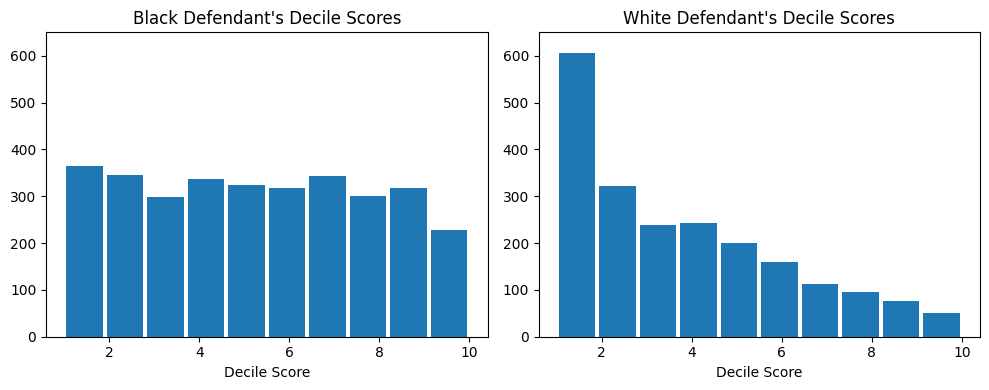

In [77]:
#Filtering data
black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

#Creates a side by side histogram plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Black defendants plot
axes[0].hist(black_df["decile_score"], bins=10, rwidth = 0.9)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

#White defendants plot
axes[1].hist(white_df["decile_score"], bins=10, rwidth = 0.9)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

###Interpretation
The White defendants distribution is more rightly-skewed, with more observations in the lower deciles. On the other hand, the Black defendants are more evenly distributed across the decile score range.

In [78]:
#Cross-tabs decile score by race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [79]:
#fitting the log model
model_glm = smf.glm(
    "score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model_glm.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[HighScore]', 'score_factor[LowScore]']   No. Observations:                 6172
Model:                                                               GLM   Df Residuals:                     6160
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -3084.2
Date:                                                   Sun, 05 Apr 2026   Deviance:                       6168.4
Time:                                                           18:50:26   Pearson chi2:                 6.07e+03
No. Iterations:                                                        6   Pseudo R-squ.

###Interpretation:
The logistic regression model predicts whether someone received a high COMPAS score based on features like gender, age, race, prior offenses, type of crime, and if they have reoffended in the past two years. The results illustrate that race is still an important predictor even after controlling for all other factors. Specifically, African-American defendants have a positive coefficient and it is statistically significant, meaning they are more likely to receive a high risk score compared to Caucasian defendants (who are the reference group). Other variables behave how they are expected. People with more priors and those who have recently reoffended also have positive statistically significant scores, giving them a higher chance of receiving a higher score. Younger individuals are more likely to receive scores, compared to older individuals. Gender has a slight impact as well, with females slightly more likely to have high scores than males (reference).

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior

In [80]:
#Baseline or "control" predicted probability based on intercept
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

float(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))

1.4528408658138932

Women are 19.4% more likely than men to get a higher score

In [81]:
float(np.exp(0.22127) / (1 - control + (control * np.exp(0.22127))))

1.1947978508506671

In [82]:
float(np.exp(1.30839) / (1 - control + (control * np.exp(1.30839))))

2.4961202077189455

In [83]:
#predicted probabilities
df["pred_prob"] = model_glm.predict(df)

#predicted class
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)

#map to labels
df["pred_class"] = df["pred_class"].map({0: "No Recid", 1: "Recid"})

In [84]:
print("\nOverall Confusion Matrix\n")

#confusion matrix using predicted laels vs actual recidivism
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

#confusion matrix counts
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


Overall Confusion Matrix

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


###Interpretation
The confusion matrix shows how well the model predicts those who reoffend (recidivism). Overall, the model has a 73.2% accuracy so classifying it for most cases. A precision of 72.4% indicates when a model predicts someone will reoffend, its correct about 72.4% of the time. The recall of 66.4% means the model identifies about 66.4% of reoffenders. There is a False Positive rate of 21.1% meaning that some individuals who did not reoffend are incorrectly predicted as high risk of reoffense. The false negative rate is 33.6% meaning that those individuals who reoffended are missed by the models prediction. Overall the model performs reasonably well but still makes some meaningful errors.

In [85]:
print("\nConfusion Matrix by Race\n")

# Actual and predicted binary columns for calculation
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

# Confusion matrix components within each race group
race_metrics = (
    df.groupby("race")
      .apply(lambda x: pd.Series({
          "n":  len(x),
          "TP": ((x["pred"] == 1) & (x["actual"] == 1)).sum(),
          "TN": ((x["pred"] == 0) & (x["actual"] == 0)).sum(),
          "FP": ((x["pred"] == 1) & (x["actual"] == 0)).sum(),
          "FN": ((x["pred"] == 0) & (x["actual"] == 1)).sum()
      }))
      .reset_index()
)

# Performance metrics by race
race_metrics["Accuracy"]  = round((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"], 3)
race_metrics["Precision"] = round(race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"]), 3)
race_metrics["Recall"]    = round(race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"]), 3)
race_metrics["FPR"]       = round(race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"]), 3)
race_metrics["FNR"]       = round(race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"]), 3)

# Sort by group size (same as before, just cleaner)
race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)


Confusion Matrix by Race

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


####Note:
Unsure why the chart splits and gives the future warning, I tried researching how to fix but nothing I could understand

###Interpretation
The confusion matrix by race shows the models preformance is not consistent across groups. For African-American defendants, the model has high recall meaning it correctly identifies individuals who actually reoffended, but it also has a high false positive rate, meaning more people who do not reoffend are incorrectly labeled as high risk. For caucasian defendants, the recall has a low recall of 46.4%. Although it has a low False positive rate, it has a high false negative rate of 53.6% meaning it misses more individuals who actually reoffend. Other race groups show mixed results, mainly due to the lower number of sample size, making them overall less reliable.

In [86]:
print("\nFPR and FNR Disparity by Race\n")

#Keeping only race and error-rate columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

#Caucasian defendants are the baseline comparison group
base_FPR = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
base_FNR = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

#Calculating disparities relative to the caucasian baseline calculared
disparity["delta_FPR"] = (disparity["FPR"] - base_FPR).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - base_FNR).round(3)

print(disparity)


FPR and FNR Disparity by Race

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Interpretation:
The disparity table for FPR and FNR compares the error rates across the racial groups using Caucasian as baseline. African-American defendants have a higher FPR +0.263 meaning they are more likely than Caucasian defendants to be incorrectly labeled as high risk, even though they don't reoffend. They do have a lower false negative rate (-0.363) meaning the model is less likely to miss actual reoffenders in the group. Other racial groups like Hispanic, Other, and Asian also have lower FPR but higher FNR, meaning they are less likely to be incorrectly labeled, but more likely to have actual reoffenders. Native Americans have a high delta FPR of 0.563 but thats because of the small sample rize making the results not as reliable.

##ASSIGNMENT 2 (Lecture 2 Continuation)

In [87]:
#Defining features and target variables
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)
target = "score_binary"

features = [
    "priors_count",
    "age_factor",
    "race_factor",
    "gender_factor",
    "crime_factor",
    "two_year_recid"
]


In [88]:
#Step 0 - Train/test split
from sklearn.model_selection import train_test_split

X = df[features].copy()
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4937, 6) Test: (1235, 6)


In [89]:
#Step 1 - Fit logistic regression and gradient-boosted tree
numeric_features = ["priors_count", "two_year_recid"]
category_features = ["age_factor","race_factor","gender_factor","crime_factor"]

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features)
])

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_factor', 'race_factor',
                                                   'gender_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [90]:
#Step 2 - Compare model performance by race
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(
            gdf["actual"],
            gdf["pred"],
            labels=[0, 1]   # 🔥 forces 2x2 matrix
            )
        tn, fp, fn, tp = cm.ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else 0,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else 0,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression Results")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\nGradient Boosted Tree Results")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression Results
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
2          Hispanic  108     0.824  0.063  0.483  0.831
3             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

Gradient Boosted Tree Results
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
2          Hispanic  108     0.815  0.089  0.448  0.833
3             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


###Interpretation
The results show disparities in error rates across racial groups. African-American defendants have a higher FPR (between 0.36 in Gradient boosted Tree, and 0.387 in logistic regression), compared to Caucasian defendants (around 0.09 in Gradient Boosted Tree, and 0.109 in Logistic Regression). This means that African-Americans are more likely to be incorrectly classified as high risk. Caucasians also have a higher FNR, meaning they are more likely to be incorrectly classified as low risk.

Overall accuracy and AUC are relatively good preforming, although the Asian and Native American Groups differ more than the other groups due to their low sample size values.

In [91]:
# Step 3 — LIME explanations: Black and White defendant
#!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
        list(preprocessor
        .named_transformers_["cat"]
        .get_feature_names_out(category_features))),
    class_names = ["Low", "High"],
    mode = "classification",
    discretize_continuous = True,
    random_state = 42
)

#predicted probabilities
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

#getting 4 individuals
black_subset = X_test_copy[X_test_copy["race_factor"] == "African-American"] \
    .sort_values("pred_prob")

black_low_idx = black_subset.index[0]
black_high_idx = black_subset.index[-1]


white_subset = X_test_copy[X_test_copy["race_factor"] == "Caucasian"] \
    .sort_values("pred_prob")

white_low_idx = white_subset.index[0]
white_high_idx = white_subset.index[-1]

#lime explanations
for label, idx in [
    ("Black (low risk)", black_low_idx),
    ("Black (high risk)", black_high_idx),
    ("White (low risk)", white_low_idx),
    ("White (high risk)", white_high_idx)
]:

    row_enc = preprocessor.transform(X_test.loc[[idx]])

    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")

    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


LIME: Black (low risk)
Predicted probability: 0.021
 age_factor_Less than 25 <= 0.00          -0.3614
 age_factor_Greater than 45 > 0.00        -0.2050
 0.00 < race_factor_African-American <= 1.00 +0.1075
 race_factor_Hispanic <= 0.00             +0.0955
 two_year_recid <= -0.92                  -0.0916
 priors_count <= -0.68                    -0.0581

LIME: Black (high risk)
Predicted probability: 0.999
 race_factor_Native American <= 0.00      -0.4358
 priors_count > 0.17                      +0.3847
 age_factor_Less than 25 <= 0.00          -0.3371
 age_factor_Greater than 45 <= 0.00       +0.2307
 0.00 < race_factor_African-American <= 1.00 +0.1013
 two_year_recid <= -0.92                  -0.0977

LIME: White (low risk)
Predicted probability: 0.017
 age_factor_Less than 25 <= 0.00          -0.3630
 age_factor_Greater than 45 > 0.00        -0.2232
 race_factor_African-American <= 0.00     -0.1026
 two_year_recid <= -0.92                  -0.0924
 race_factor_Hispanic <= 0.00     

## Interpretation
LIME looks at local feature explanation, and it shows how features influence models prediction of a high COMPAS risk score for each individual. The predicted probabilities clearly separate low-risk and high-risk individuals across both racial groups (near 0 for low risk and near 1 for high risk).

For both Black and White defendants, there are some similar patterns. Higher priors count increases the predicted risk, while lower priors count reduces it. Age also plays a role, being younger (less than 25) tends to decrease risk, and being older (greater than 45) slightly increases or decreases risk depending on the individual.

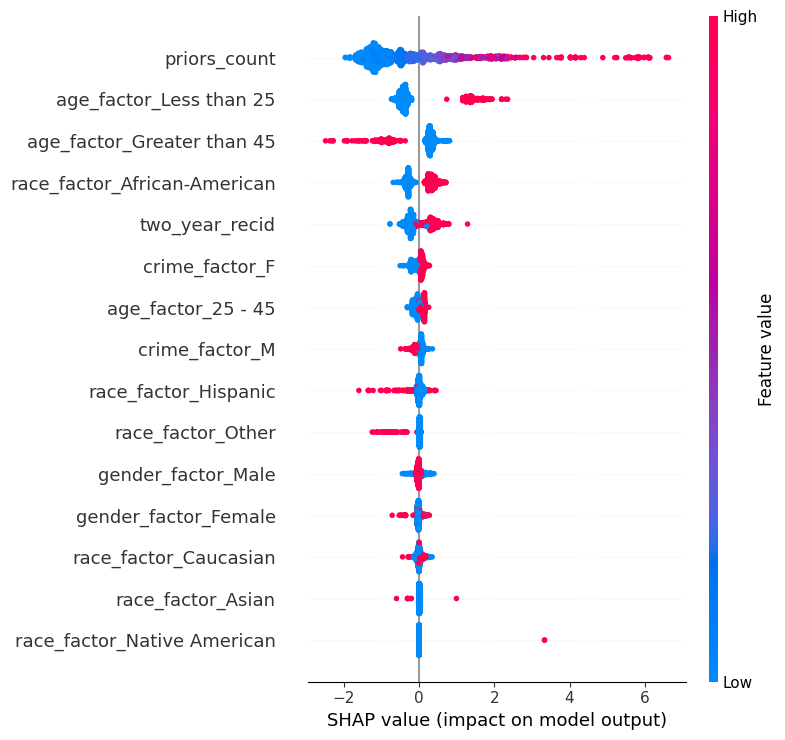

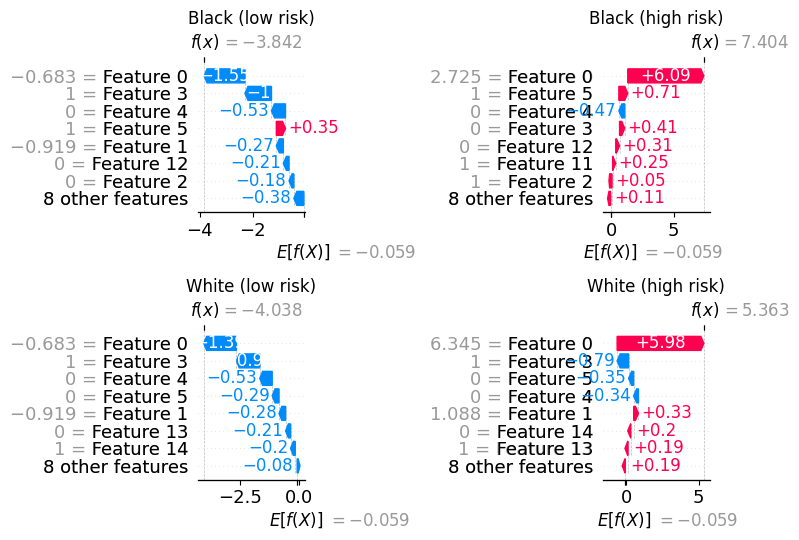

In [92]:
# Step 4 — SHAP beeswarm and waterfall: Black vs. White
#!pip install shap
import shap
import matplotlib.pyplot as plt

# Encode test data
X_test_enc = preprocessor.transform(X_test)

# Feature names
feat_names = (numeric_features +
    list(preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(category_features)))

# SHAP explainer
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)


# same 4 individuals
indices = [
    ("Black (low risk)", black_low_idx),
    ("Black (high risk)", black_high_idx),
    ("White (low risk)", white_low_idx),
    ("White (high risk)", white_high_idx)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (label, idx) in zip(axes.flatten(), indices):
    loc = X_test.index.get_loc(idx)

    plt.sca(ax)
    shap.waterfall_plot(
        shap_values[loc],
        max_display=8,
        show=False
    )
    ax.set_title(label)

plt.tight_layout()
plt.show()

In [93]:
for i, name in enumerate(feat_names):
    print(i, name)

0 priors_count
1 two_year_recid
2 age_factor_25 - 45
3 age_factor_Greater than 45
4 age_factor_Less than 25
5 race_factor_African-American
6 race_factor_Asian
7 race_factor_Caucasian
8 race_factor_Hispanic
9 race_factor_Native American
10 race_factor_Other
11 gender_factor_Female
12 gender_factor_Male
13 crime_factor_F
14 crime_factor_M


##Interpretation
The SHAP beeswarm plot shows priors_count and age are the most important drivers of the models prediction. Meaning a higher priors_count will push predictions toward a higher COMPAS risk score. Older age, specifically older than 45, tends to decrease predicted risk. Being less than 25 seems to push predictions towards a higher predicted risk score as well.

The waterfall plots visualize how these features affect individual predictions.

For LIME and SHAP they agree in the fact that they both show that priors_count is the main factor or contributor, and age also consistently matters. In both methods, higher priors increase risk, and lower priors decrease it. This agreement suggests the model is largely driven by criminal history variables.

They diverge in some ways. SHAP provides a more consistent, global view of feature importance across all observations, while LIME focuses on local explanations and sometimes highlights slightly different feature contributions for individual cases. LIME places a bit more noticable emphasis on race-related features in specific cases, while SHAP shows these effects are generally smaller compared to priors_count.

The divergence implies for the governance that relying on only one explanation method can be misleading. Since LIME and SHAP can highlight different aspects of the model, governance should require multiple explanation methods to ensure robustness. It also suggests the need for monitoring sensitive attributes (like race) are indirectly influencing predictions like in proxy variables, even if they are not the main drivers. This supports a governance framework where both individual-level explanations (LIME) and global consistency checks (SHAP) are used together to detect potential bias and ensure a fair model.

In [94]:
#!pip install dice-ml
import dice_ml
from dice_ml import Dice
import pandas as pd

#Use same features
dice_features = [
    "priors_count",
    "age_factor",
    "race_factor",
    "gender_factor",
    "crime_factor",
    "two_year_recid"
]

X_train_dice = X_train[dice_features].copy()
X_test_dice = X_test[dice_features].copy()

#Ensure numeric where needed
X_train_dice["priors_count"] = pd.to_numeric(X_train_dice["priors_count"], errors="coerce")
X_test_dice["priors_count"] = pd.to_numeric(X_test_dice["priors_count"], errors="coerce")
X_train_dice["two_year_recid"] = pd.to_numeric(X_train_dice["two_year_recid"], errors="coerce")
X_test_dice["two_year_recid"] = pd.to_numeric(X_test_dice["two_year_recid"], errors="coerce")

#Target
target = "score_binary"

y_train_dice = y_train.copy()
y_train_dice = y_train_dice.rename(target)

#combine
dice_df = pd.concat([X_train_dice, y_train_dice], axis=1)

#DiCE setup
dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=["priors_count"],
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

features_to_vary = ["age_factor", "priors_count", "crime_factor"]


#for same four individuals
for label, idx in [
    ("Black (low risk)", black_low_idx),
    ("Black (high risk)", black_high_idx),
    ("White (low risk)", white_low_idx),
    ("White (high risk)", white_high_idx)
]:

    query = X_test_dice.loc[[idx]].copy()

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={"priors_count": [0, 38]},
        features_to_vary=features_to_vary
    )

    print(f"\nDiCE counterfactuals: {label}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  6.60it/s]


DiCE counterfactuals: Black (low risk)
Query instance (original outcome : 0)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid,score_binary
0,0,Greater than 45,African-American,Female,M,0,0



Diverse Counterfactual set (new outcome: 1)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid,score_binary
0,18,Less than 25,-,-,-,-,1
1,24,25 - 45,-,-,-,-,1
2,-,Less than 25,-,-,-,-,1


...

100%|██████████| 1/1 [00:00<00:00,  6.82it/s]


DiCE counterfactuals: White (high risk)
Query instance (original outcome : 1)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid,score_binary
0,33,Greater than 45,Caucasian,Male,F,1,1



Diverse Counterfactual set (new outcome: 0)


,priors_count,age_factor,race_factor,gender_factor,crime_factor,two_year_recid,score_binary
0,4,-,-,-,-,-,0
1,15,-,-,-,M,-,0
2,10,-,-,-,M,-,0


## Interpretation:
For the Black defendant with a low risk (0), the model suggests that the minimal change needed to flip the prediction to high risk (1) is mainly an increase in priors_count. In counterfactuals, priors_count increases substantially (up to 20+), which pushes the prediction to high risk. Also changing crime_factor (from M to F) also contributes.

For the Black defendant with a high risk (1), the model suggests that the minimal changes to get to low risk (0) involve reducing priors_count (to vals like 0–5) and sometimes increasing age to “Greater than 45.” These changes reduce the predicted risk.

For the White defendant with a low risk (0), the model suggests that changing to high risk (1) requires a large increase in priors_count (15–33). Compared to the Black defendant, the required increase in priors is still large.

For the White defendant with a high risk (1), the model suggests that reducing priors_count (down to 2–11) is enough to change the prediction to low risk.

Overall, across all individuals, the minimal feature changes required to change predictions are primarily changes in priors_count, with occasional contributions from age or crime type. None of the counterfactuals require changes to immutable features like race or gender. This suggests the model does not directly depend on these features to change predictions.

# Governance Memo

To the court auditor, this memo evaluates how the COMPAS model behaves and whether there are fairness concerns, using LIME, SHAP, and counterfactual explanations in DiCE.

Across all three methods, the model is fairly consistent in what drives predictions. The most impactful features are priors_count and age. SHAP results show that prior criminal history has the largest overall influence, with age also shifts risk as well. The LIME explanations on the individual cases show that similarly, with higher priors and younger age increasing predicted risk, and lower priors count and older age decrease it. Overall, the model relys heavily on those features.

There are still some concerns when comparing outcomes across groups. Within our overall analysis, Black defendants received higher predicted risk than White defendants, even looking at similar types of features. The counterfactuals reinforce this idea, with a larger increase in priors count for white defendants compared to black defendants in order to reach the high risk category. This suggests that even if race isn't looked at directly, there is still some concern for fairness and if race can be shown through other proxy features.

The disparity also is reflected in the group-level error rates. Black defendants tend to have higher false positive rates (FPR), meaning they are are more likely to be incorrectly classified as high risk. On the other hand, white defendants often have higher false negative rates (FNR), meaning they are more likely to be incorrectly labeled as low risk. This imbalance is important because it implies that Black individuals may be classified as high risk more.

Each explanation also has limitations. LIME only explains one prediction at a time since it's local. SHAP assumes additive effects and might miss some of the more complex relationships. DiCE produces some of the "what-if" scenarios, but these changes might not always happen in practice.

Given the findings, I'd give the reccommendation of continued monitoring of group-level fairness metrics, especially in the differences of the error-rates.Occasional audits and rechecks of the SHAP and LIME models will help ensure fairness as well. Overall the model appears reasonable in structure, but the differences observed should be taken into considerations especially in the high-stakes setting of the criminal justice system.


#ASSIGNMENT 3

In [95]:
#Clean dataset
df = df.copy()

df["high_risk"] = (df['score_factor'] == "HighScore").astype(int)
df['race'] = df['race_factor']
df['sex'] = df['gender_factor']

print(df[['race','sex','high_risk','two_year_recid','decile_score']].head())

               race   sex  high_risk two_year_recid  decile_score
0             Other  Male          0              0             1
1  African-American  Male          0              1             3
2  African-American  Male          0              1             4
5             Other  Male          0              0             1
6         Caucasian  Male          1              1             6


In [96]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
#!pip install solas-ai
import solas_disparity as sd

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          1              1


# Step 1: AIR and Marginal Effect by race


In [97]:
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               


###Interpretation:
The results show some differences in the selection rates across races. African-American defendants have a higher likelihood of being classified as high risk compared to Caucasians (0.576 to 0.33 respectively). Their AIR's also are greater than 1 and have a positive marginal effect.

Asian and Other groups have AIR values below 0.8 threshold, indicating potential adverse impact

In [98]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


The two proportion z-test shows that the difference between African American and Caucasian selection rates are statistically significant with the p-value a near 0, suggesting it may not be random.

#AIR and Marginal Effect by Sex

In [99]:
sr_sex = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print(sr_sex.sort_values('AIR').to_string(index=False))

# Two-proportion z-test: Female vs Male
groups = ['Female', 'Male']
ns = df[df['sex'].isin(groups)].groupby('sex')['high_risk'].count()
events = df[df['sex'].isin(groups)].groupby('sex')['high_risk'].sum()

stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nSex z-test: z = {stat:.3f}, p = {pval:.4f}")

   sex  selection_rate      AIR        ME flag_80
Female        0.405106 0.889809 -0.050167        
  Male        0.455273 1.000000  0.000000        

Sex z-test: z = -3.113, p = 0.0019


###Interpretation:
Looking at the selection rate, AIR, and ME with the sex variable now. Females have a slightly slower selection rate compared to males with AIR of 0.889. This doesn't fall below the 80% threshold, but the ME is negative (-0.050167) meaning that females are somwhat less likely to be classified as high risk. The z-test also shows the statistically significant difference with a p val < 0.05.

# Step 2: Error-Rate Disparity Analysis

In [100]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        results.append({
            group_col: grp,
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })

    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}, FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710
African-American: FPR=0.423, FNR=0.285
Caucasian: FPR=0.220, FNR=0.496


African American defendents have a higher FPR compared to other racial groups, especially Caucasian defendants (0.423 and 0.22 respectively). Native Americans also are high but this is due to the very small sample size of 11. The FPR disprity means that African-American individuals are more likely to be incorrectly classified as high risk, even when they do not reoffend. On the other hand, Caucasians have a higher false negative rate (0.496) compared to African Americans (0.2847). Meaning that the model is likely to incorrectly classify Caucasian individuals as low risk when they actually do reoffend.

# Step 3: Standardized Mean Difference

In [101]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
  sc = g[score_col]
  pooled = np.sqrt((ref.var() + sc.var()) / 2)
  d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
  mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
  results.append({group_col: grp,
                  'mean_score': round(sc.mean(), 3),
                  'SMD': round(d, 3),
                  'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

           race  mean_score   SMD  magnitude
Native American       6.455 1.008 very large


SMD shows the substantial differences in the COMPAS decile scores. Native American defendants have a mean score of 6.455 and a SMD of 1.008 relative to the reference group Caucasians. This is a very large effect, this means that their average risk score is significantly higher than the reference group. However, we do know that Native Americans have a very small sample size in this population which can create high variability.

#Standardized Mean Difference for Sex

In [102]:
smd_sex_tbl = smd(df, 'sex', 'decile_score', ref_group='Male')
print(smd_sex_tbl.sort_values('SMD').to_string(index=False))

   sex  mean_score    SMD magnitude
Female       4.064 -0.158     small


SMD results for sex show a small magnitude of difference. Female defendants have a slightly lower score of 4.064 compared to Males, with SMD of -0.158. This shows that while there is a difference in the scores between male and females, the magnitude effect of the disparity is small

**NOTE**
solas-ai produces identicla results in terms of the format etc, AIR, ME, and SMD all compute different things but the code was formatted and used similarly with sex and race groups

# Step 4: Intersectional Subgroup Analysis

In [103]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)

# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()

sub_rates = (
    df_sub.groupby('subgroup')['high_risk']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'selection_rate', 'count': 'n'})
    .reset_index()
)

ref_rate = sub_rates.loc[
    sub_rates['subgroup'] == 'Caucasian / Male', 'selection_rate'
].values[0]

sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(
    lambda x: '*** BELOW 0.80' if x < 0.80 else ''
)

print(sub_rates.sort_values('AIR').to_string(index=False))

worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(
    f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
    f"n={worst['n']}"
)

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst: Hispanic / Female, AIR=0.270 and n=82


The intersectional subgroup analysis shows disparities can become more pronounced when the variables are interacted or combined with eachother, When doing this, groups come out with low AIRs, indicating potential adverse impact thats not fully visible when analyzing sex or race seperately.

The worst preforming subgroup is Hispanic females, with an AIR of 0.27, relative to the Caucasian male group. This means their selection rate of being high risk is only about 27% of the reference groups rate, which is very below the 0.8 threshold indicating disparity.

# Grouped Bar Chart of FPR and FNR by Race

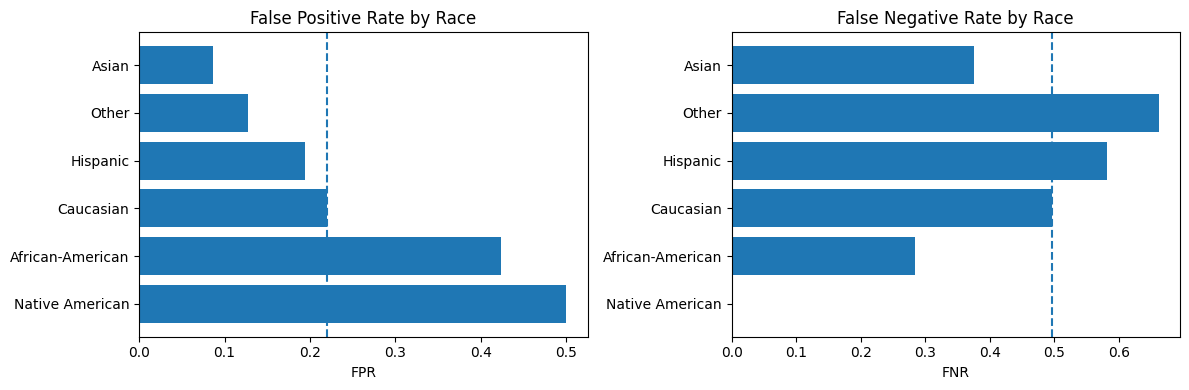

In [104]:
#FPR and FNR by race plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

er_plot = er.sort_values('FPR', ascending=False)

for ax, metric, title in [
    (axes[0], 'FPR', 'False Positive Rate by Race'),
    (axes[1], 'FNR', 'False Negative Rate by Race')
]:
    ax.barh(er_plot['race'], er_plot[metric])

    #Caucasian baseline
    baseline = er_plot.loc[er_plot['race'] == 'Caucasian', metric].values[0]
    ax.axvline(baseline, linestyle='--')

    ax.set_xlabel(metric)
    ax.set_title(title)

plt.tight_layout()
plt.show()

The figure compares the FPR and FNR by race, using Caucasian defendants as the reference group which can be visualized by the dashed line. This is a good visualization of the code and analysis mentioned before.

##Compliance Memo
This memo summarizes findings, metrics used, and limitations in the COMPAS risk assessment model.

We assesed fairness using Adverse Impact Ratio (AIR), Marginal Effect (ME), Standard Mean Difference (SMD), and error-rate disparities (FPR and FNR), which are all established regulatory and techincal practices. AIR compared selection rates across groups relative to the reference group, evaluating using the 80% threshold. ME measures the absolute difference in the selection rate, and SMD captures the difference in the average risk score. We can compare the results to determine any potential disparity or potential adverse impact.

The results we found indicate disparities across race. African-American defendants have a higher selection rate than Caucasian reference group, with an AIR > 1, while Asian and Other racial groups fall below the 0.8 theshold indicating that potential adverse impact. These differences are statistically significant after running z-tests. Error rate analysis also shows African American defendants have a higher FPR, while Caucasians have a higher FNR. This means that the model does not have equalized odds, which is a key fairness criteria. Intersectional analysis also revealed more disparity when sex and racial groups were combined. They revealed Hispanic females have the lowest AIR of approximately 0.27.

There are some limitations, as noted in some literature such as Fairness and Machine Learning book, that note statistical fairness metrics are more observational and can't establish causality or even fully capture the discrimination. Also are a lot of different criteria for the definition of fairness, so some might conflict with each other so it's hard to achieve the idea of overall fairness. Additionally, as seen in the model Native Americans have a low sample size, which reduces some of the reliability with those results.

Overall, the model notes findings of disparities in the models outcomes with race and intersectional subgroups.